# SCF challenge (minimal DFTpy)

Write you own scf cycle

## KS SCF loop 

Given an input density `rho_in` on the grid (in the cells below we call it `nin`, like the working code):

1. Build the **Kohn–Sham potential** `v_s`. 

2. Form `H = Hamiltonian(v=Vvs)` and **diagonalize** to get eigenvalues `ε_i` and orbitals `ψ_i`.  

3. Choose **occupations** `f_i` (here: Fermi–Dirac smearing) so that `∑_i f_i = N_electrons` (with spin factor).  

4. Build the **output density** `ρ_out(r) = ∑_i f_i |ψ_i(r)|²`.  

5. **Mix** `ρ_in` and `ρ_out` (e.g. linear or Pulay), update `ρ_in`, and stop when `‖ρ_in − ρ_out‖` is small enough.

### Use DFTpy to setup all you need


```python
# 0) Build you inital guess density using DFTpy
rho0 = DirectField(grid=grid)
rho0[:] = ions.get_ncharges()/ions.cell.volume

# 1) KS potential: evaluate XC + Hartree + pseudo [+ EXT] at the current density
xc = Functional(type='XC',name='LDA')
hartree = Functional(type='HARTREE')
pseudo = Functional(type='PSEUDO', grid=grid, ions=ions, PP_list=PP_list)
totalfunctional = TotalFunctional(XC=xc, HARTREE=hartree, PSEUDO=pseudo)

v_s = totalfunctional(rho0).potential

# 2) Hamiltonian on the same grid and diagonalize (lowest numeig eigenpairs)
H = Hamiltonian(v=V_s)
eig, psi = H.diagonalize(numeig=numeig)


# 3) Fermi–Dirac occupations: target \(∑ occ = N_elec / SPIN_DOF\), then scale by SPIN_DOF
N_occ = N_elec / SPIN_DOF
occ, mu = fermi_dirac_occupations(eig, N_occ, theta)
occ = occ * SPIN_DOF

# 4) New density ρ_out = Σ_i f_i |ψ_i|²
nout = DirectField(grid=nin.grid, data=sum_band_density(occ, psi))

# 5) Residual and Pulay mix → next trial density nin
res = 0.5 * np.abs(nin - nout).integral()
nin = mixer(nin, nout, coef=alpha)  # linear mixing: nin = alpha * nout + (1 - alpha) * nin
```

Wrap these lines in a `for` loop (max `N_SCF_MAX` times) and `break` when `res < 1e-6` (or similar). The reference implementation `run_scf_reference` in this notebook is exactly this pattern.


### Code structure


The cells below give a general sttructure for you to inplement the scf loop


In [2]:
# # Download files
!wget https://gitlab.com/pavanello-research-group/dftpy/-/raw/master/examples/DATA/Mg8.vasp
!wget https://gitlab.com/pavanello-research-group/dftpy/-/raw/master/examples/DATA/Mg_OEPP_PZ.UPF

--2026-05-19 14:41:38--  https://gitlab.com/pavanello-research-group/dftpy/-/raw/master/examples/DATA/Mg8.vasp
Resolving gitlab.com (gitlab.com)... 172.65.251.78, 2606:4700:90:0:f22e:fbec:5bed:a9b9
Connecting to gitlab.com (gitlab.com)|172.65.251.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 839 [text/plain]
Saving to: ‘Mg8.vasp’

Mg8.vasp            100%[===================>]     839  --.-KB/s    in 0s      

2026-05-19 14:41:38 (400 MB/s) - ‘Mg8.vasp’ saved [839/839]

--2026-05-19 14:41:39--  https://gitlab.com/pavanello-research-group/dftpy/-/raw/master/examples/DATA/Mg_OEPP_PZ.UPF
Resolving gitlab.com (gitlab.com)... 172.65.251.78, 2606:4700:90:0:f22e:fbec:5bed:a9b9
Connecting to gitlab.com (gitlab.com)|172.65.251.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 98081 (96K) [text/plain]
Saving to: ‘Mg_OEPP_PZ.UPF’

Mg_OEPP_PZ.UPF      100%[===================>]  95.78K  --.-KB/s    in 0.02s   

2026-05-19 14:41:39 (4.32 MB/

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from dftpy.grid import DirectGrid
from dftpy.field import DirectField
from dftpy.functional import Functional, TotalFunctional
from dftpy.td.hamiltonian import Hamiltonian
from dftpy.ions import Ions
from dftpy.formats import io
from dftpy.functional.external_potential import ExternalPotential
from dftpy.mixer.pulay import PulayMixer


In [4]:
VASPR = "Mg8.vasp"          # structure
PP_LIST = ["./Mg_OEPP_PZ.UPF"]
ECUT = 4                    # this is a small value, so the SCF converges fast (increase for production)
N_SCF_MAX = 30
MIX_ALPHA = 0.1
SMEARING = 1e-3             # Fermi–Dirac temperature (Ry)
SPIN_DOF = 2                # spin degeneracy (2 = non-magnetic closed shell)

In [5]:
# --- Load ions / grid / uniform start density ---
ions = io.read(VASPR, format="vasp", names=["Mg"])
grid = DirectGrid(ions.cell, ecut=ECUT)

xc = Functional(type="XC", name="LDA")
hartree = Functional(type="HARTREE")
pseudo = Functional(type="PSEUDO", grid=grid, ions=ions, PP_list=PP_LIST)

rho0 = DirectField(grid=grid)
rho0[:] = ions.get_ncharges() / ions.cell.volume

N_elec = ions.get_ncharges()  # total valence electrons (Ry convention in this workflow)
numeig = int(np.ceil((N_elec / SPIN_DOF) * 1.8))
print("N_electrons:", N_elec, " numeig:", numeig, " grid nr:", grid.nr)


setting key: Mg -> ./Mg_OEPP_PZ.UPF
N_electrons: 16.0  numeig: 15  grid nr: [36 36 32]


In [6]:
def fermi_dirac_occupations(eig, N, theta, tol=1e-10, max_iter=200):
    """Return (occupations per spin-orbital, mu) for fractional N at temperature theta."""
    eig = np.array(eig, dtype=float)
    if theta <= 0:
        raise ValueError("theta must be positive")

    def total_occupation(mu):
        return np.sum(1.0 / (1.0 + np.exp((eig - mu) / theta)))

    mu_min = np.min(eig) - 20 * theta
    mu_max = np.max(eig) + 20 * theta
    for _ in range(max_iter):
        mu = 0.5 * (mu_min + mu_max)
        occ_sum = total_occupation(mu)
        if abs(occ_sum - N) < tol:
            occ = 1.0 / (1.0 + np.exp((eig - mu) / theta))
            return occ, mu
        if occ_sum < N:
            mu_min = mu
        else:
            mu_max = mu
    raise RuntimeError("Fermi level not converged")


def sum_band_density(occupations, psi):
    """ρ(r) = Σ_i f_i |ψ_i(r)|² on the grid."""
    n_psi = np.conj(psi) * psi
    return np.einsum("i,ijkl->jkl", occupations, n_psi)


### Your SCF loop

With `USE_REFERENCE_SCF = False`, implement `run_scf_student`. With `True`, the reference `run_scf_reference` from the long notebook is used.


In [ ]:
def run_scf(rho_in, niter=N_SCF_MAX, alpha=MIX_ALPHA, theta=SMEARING, numeig=numeig):
    """
    Implement the SCF loop here (see markdown above).
    Must return: rho_out (DirectField), occupations, eigval, psi
    """
    mixer = PulayMixer(mp=None, delay=0, maxm=10)
    mixer.restart()
    pseudo_loc = Functional(type="PSEUDO", grid=rho_in.grid, ions=ions, PP_list=PP_LIST)
    tf = TotalFunctional(XC=xc, HARTREE=hartree, PSEUDO=pseudo_loc)
    nin = rho_in
    # # --- WRITE YOUR SCF CODE IN HERE: loop niter times (uncomment & adjust, or copy from run_scf_reference) ---
    # # nout = occ = eig = psi = None
    # for _ in range(niter):
    #     H = Hamiltonian(v=tf(nin).potential)
    #     eig, psi = H.diagonalize(numeig=numeig)
    #     occ, _ = fermi_dirac_occupations(eig, N_elec / SPIN_DOF, theta)
    #     occ = occ * SPIN_DOF
    #     nout = DirectField(grid=nin.grid, data=sum_band_density(occ, psi))
    #     res = 0.5 * np.abs(nin - nout).integral()
    #     print("SCF residual :", float(res))
    #     nin = mixer(nin, nout, coef=alpha)
    #     if res < 1e-6:
    #         print("converged")
    #         break
    return nout, occ, np.array(eig), np.array(psi)




In [8]:
rho_out, occs, eig, psi = run_scf(rho0)
rho_ks = rho_out  # DirectField from SCF
print("Integral(2*rho):", rho_ks.integral() * 2)


setting key: Mg -> ./Mg_OEPP_PZ.UPF
SCF residual (student): 15.683815594550307
SCF residual (student): 14.090869790100186
SCF residual (student): 10.535204387138684
SCF residual (student): 8.652786877719409
SCF residual (student): 8.206033979867954
SCF residual (student): 3.9045773714691756
SCF residual (student): 4.22697836971843
SCF residual (student): 3.270702261882064
SCF residual (student): 2.5398671690825463
SCF residual (student): 0.982628222925574
SCF residual (student): 0.6507133311247397
SCF residual (student): 0.6294104885169245
SCF residual (student): 0.1270710775350938
SCF residual (student): 0.11515102074117234
SCF residual (student): 0.012073593230378666
SCF residual (student): 0.009992841329412942
SCF residual (student): 0.005962552933896358
SCF residual (student): 0.0005483300884370314
SCF residual (student): 0.0004680999268277174
SCF residual (student): 8.154904339344615e-05
SCF residual (student): 8.342392644216245e-05
SCF residual (student): 1.4556013235884982e-05
S

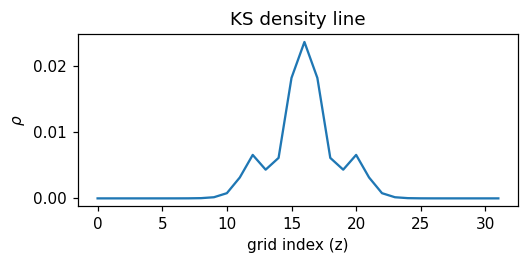

In [9]:
# Quick plot: density along last axis through cell center
ix, iy = rho_ks.grid.nr[0] // 2, rho_ks.grid.nr[1] // 2
plt.figure(figsize=(5, 2.5), dpi=110)
plt.plot(rho_ks[ix, iy, :].flatten())
plt.xlabel("grid index (z)")
plt.ylabel(r"$\rho$")
plt.title("KS density line")
plt.tight_layout()
plt.show()


### Optional: write XSF

`rho_ks.write("rho_ks_challenge.xsf", ions)`


In [ ]:
# rho_ks.write("rho_ks_challenge.xsf", ions)
